# Import a two-dimensional figure-eight geometry into MuMax3

This modernizes the original Mathematica `Rasterize["8"]` experiment. Python renders an antialiased glyph into a 256 × 256 fill-fraction mask, OVFToolkit writes it as a scalar OVF geometry, and MuMax3's `ext_InitGeomFromOVF` initializes the mesh and geometry directly from that file.

The Go engine function is named `InitGeomFromOVF`; MuMax3 scripts expose it as `ext_InitGeomFromOVF`. No custom Go executable is needed.


## Set up a disposable workspace

The notebook locates its own directory regardless of where Jupyter was launched.


In [5]:
%pip install -q ipynbname matplotlib pillow

import os
import shutil
import subprocess
import tempfile
from pathlib import Path

import ipynbname
import matplotlib.pyplot as plt
import numpy as np
import ovftoolkit as ovf

if "work_dir" in globals():
    shutil.rmtree(work_dir, ignore_errors=True)

try:
    notebook_directory = ipynbname.path().parent
except (FileNotFoundError, IndexError):
    # Headless executors such as nbconvert cannot query a notebook server.
    notebook_directory = Path(
        os.environ.get("OVFTOOLKIT_NOTEBOOK_DIR", Path.cwd())
    ).resolve()
work_dir = Path(tempfile.mkdtemp(prefix="ovftoolkit-imported-geometry-"))

configured_mumax = os.environ.get("MUMAX3")
mumax3 = Path(configured_mumax or shutil.which("mumax3") or "")
if not mumax3.is_file():
    raise RuntimeError("mumax3 was not found; put it on PATH or set MUMAX3")
mumax3 = mumax3.resolve()
print(f"Temporary workspace: {work_dir}")
print(f"MuMax3: {mumax3}")
from matplotlib import font_manager
from PIL import Image, ImageDraw, ImageFont

Note: you may need to restart the kernel to use updated packages.
Temporary workspace: C:\Users\Artej\AppData\Local\Temp\ovftoolkit-imported-geometry-yljltm_6
MuMax3: C:\Users\Artej\go\bin\mumax3.exe


## Rasterize the figure eight and export a scalar OVF geometry

Rendering at four times the requested resolution and downsampling preserves fractional edge coverage. MuMax3 consumes these values directly as cell fill fractions.


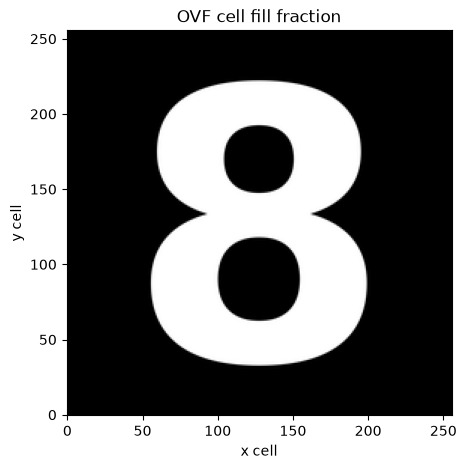

C:\Users\Artej\AppData\Local\Temp\ovftoolkit-imported-geometry-yljltm_6\figure-eight-geometry.ovf


In [6]:
resolution = 256
supersampling = 4
high_resolution = resolution * supersampling

font_path = font_manager.findfont(
    font_manager.FontProperties(family="DejaVu Sans", weight="bold")
)
font = ImageFont.truetype(font_path, int(0.98 * high_resolution))
canvas = Image.new("L", (high_resolution, high_resolution), 0)
draw = ImageDraw.Draw(canvas)
box = draw.textbbox((0, 0), "8", font=font)
position = (
    (high_resolution - (box[2] - box[0])) / 2 - box[0],
    (high_resolution - (box[3] - box[1])) / 2 - box[1],
)
draw.text(position, "8", font=font, fill=255)
canvas = canvas.resize((resolution, resolution), Image.Resampling.LANCZOS)
# Image rows run top-to-bottom; OVF y coordinates run bottom-to-top.
fill = np.flipud(np.asarray(canvas, dtype=np.float32) / 255)

geometry = ovf.VField()
geometry.data = fill[np.newaxis, ..., np.newaxis]
geometry.dummy_header((1e-9, 1e-9, 5e-9))
geometry.header["Title"] = "Antialiased figure-eight geometry"
geometry.header["Desc"] = "Scalar cell fill fraction generated from DejaVu Sans Bold"
geometry_file = work_dir / "figure-eight-geometry.ovf"
with ovf.writer(geometry_file) as destination:
    destination.write(geometry)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(fill, cmap="gray", vmin=0, vmax=1, origin="lower")
ax.set(title="OVF cell fill fraction", xlabel="x cell", ylabel="y cell")
plt.show()
print(geometry_file)

## Initialize and relax the imported geometry in MuMax3

`ext_InitGeomFromOVF` obtains the grid size and cell size from the OVF header. Forward slashes are used in the generated script so Windows paths cannot become MuMax escape sequences.


In [7]:
template = notebook_directory / "figure-eight.mx3.in"
source_file = work_dir / "figure-eight.mx3"
output_dir = work_dir / "figure-eight.out"
text = template.read_text(encoding="utf-8")
if text.count("@GEOMETRY_FILE@") != 1:
    raise ValueError("Expected exactly one @GEOMETRY_FILE@ placeholder")
source_file.write_text(
    text.replace("@GEOMETRY_FILE@", geometry_file.resolve().as_posix()),
    encoding="utf-8",
)
subprocess.run([str(mumax3), "-o", str(output_dir), str(source_file)], check=True)

CompletedProcess(args=['C:\\Users\\Artej\\go\\bin\\mumax3.exe', '-o', 'C:\\Users\\Artej\\AppData\\Local\\Temp\\ovftoolkit-imported-geometry-yljltm_6\\figure-eight.out', 'C:\\Users\\Artej\\AppData\\Local\\Temp\\ovftoolkit-imported-geometry-yljltm_6\\figure-eight.mx3'], returncode=0)

## Inspect the relaxed magnetization and in-plane demagnetizing field

The geometry remains a 2D problem. Color shows the relaxed out-of-plane magnetization, while the sparse streamlines show the in-plane projection of `B_demag`.


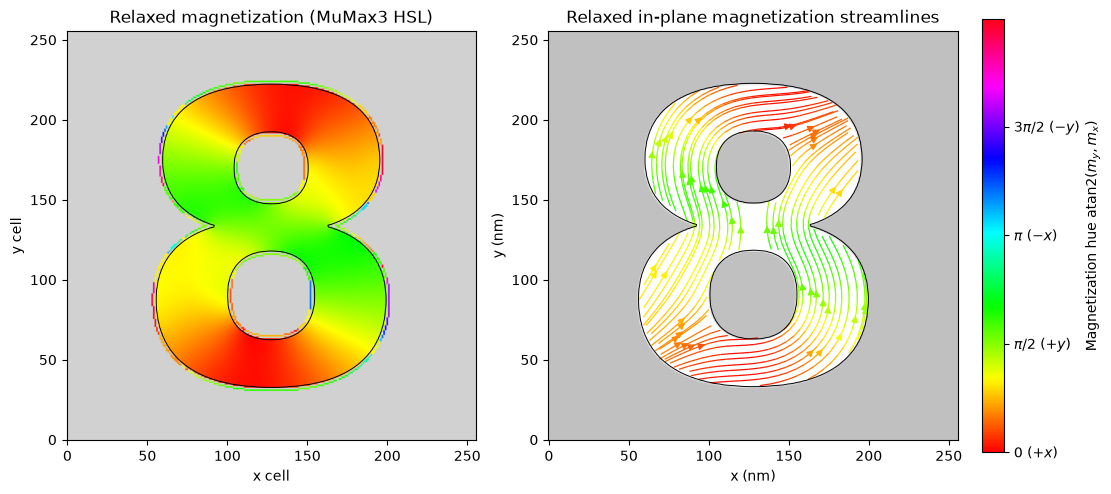

In [8]:
from matplotlib import colors

def load_single(path):
    with ovf.reader(path) as source:
        return source[0]

def mumax_hsl_rgb(vector):
    """Vectorized equivalent of MuMax3 draw.HSLMap."""
    hue = np.mod(np.arctan2(vector[..., 1], vector[..., 0]), 2 * np.pi) / (2 * np.pi)
    saturation_hsl = np.clip(np.linalg.norm(vector, axis=-1), 0, 1)
    lightness = np.clip(0.5 * vector[..., 2] + 0.5, 0, 1)

    # Matplotlib provides HSV rather than HSL; convert HSL to its equivalent HSV.
    value = lightness + saturation_hsl * np.minimum(lightness, 1 - lightness)
    saturation_hsv = np.divide(
        2 * (value - lightness),
        value,
        out=np.zeros_like(value),
        where=value > 0,
    )
    return colors.hsv_to_rgb(np.stack((hue, saturation_hsv, value), axis=-1)), hue

result_geometry = load_single(output_dir / "geometry.ovf")
magnetization = load_single(output_dir / "magnetization.ovf")
x, y, _ = magnetization.meshgrid()

mask = result_geometry.data[0, ..., 0]
m = magnetization.data[0]

# MuMax3 convention: hue=atan2(my,mx), saturation=|m|, lightness=(mz+1)/2.
magnetization_rgb, magnetization_hue = mumax_hsl_rgb(m)
magnetization_rgb[mask <= 0] = 0.82

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
axes[0].imshow(magnetization_rgb, origin="lower")
axes[0].contour(mask, levels=[0.5], colors="black", linewidths=0.7)
axes[0].set(title="Relaxed magnetization (MuMax3 HSL)", xlabel="x cell", ylabel="y cell")

mx = np.where(mask > 0, m[..., 0], np.nan)
my = np.where(mask > 0, m[..., 1], np.nan)
axes[1].imshow(mask, origin="lower", cmap="gray", vmin=0, vmax=1, alpha=0.25)
stream = axes[1].streamplot(
    x[0] * 1e9, y[0] * 1e9, mx, my,
    color=magnetization_hue, cmap="hsv", density=1.4, linewidth=0.9,
    broken_streamlines=False,
)
axes[1].contour(
    x[0] * 1e9, y[0] * 1e9, mask,
    levels=[0.5], colors="black", linewidths=0.7,
)
axes[1].set(title="Relaxed in-plane magnetization streamlines", xlabel="x (nm)", ylabel="y (nm)")
colorbar = fig.colorbar(stream.lines, ax=axes[1], ticks=[0, 0.25, 0.5, 0.75, 1])
colorbar.set_ticklabels([
    r"$0$ ($+x$)", r"$\pi/2$ ($+y$)", r"$\pi$ ($-x$)",
    r"$3\pi/2$ ($-y$)", r"$2\pi$ ($+x$)",
])
colorbar.set_label(r"Magnetization hue $\operatorname{atan2}(m_y,m_x)$")
plt.show()

## Clean up

Run this only after retaining any generated files you want.


In [9]:
shutil.rmtree(work_dir)
print(f"Removed temporary workspace: {work_dir}")

Removed temporary workspace: C:\Users\Artej\AppData\Local\Temp\ovftoolkit-imported-geometry-yljltm_6
